In [ ]:
import os
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from dotenv import load_dotenv
from rfml_uav.drone_rf.consts import BUI_dict

load_dotenv()

True

In [2]:
results_path = os.getenv("RESULTS_PATH")
save_path = os.path.join(results_path, "figures")
os.makedirs(save_path, exist_ok=True)

features = ["PSD", "STFT", "Wavelets"]
models = ["CNN", "RNN"]
columns = ["True", "Predicted"]
labels = list(BUI_dict.keys())

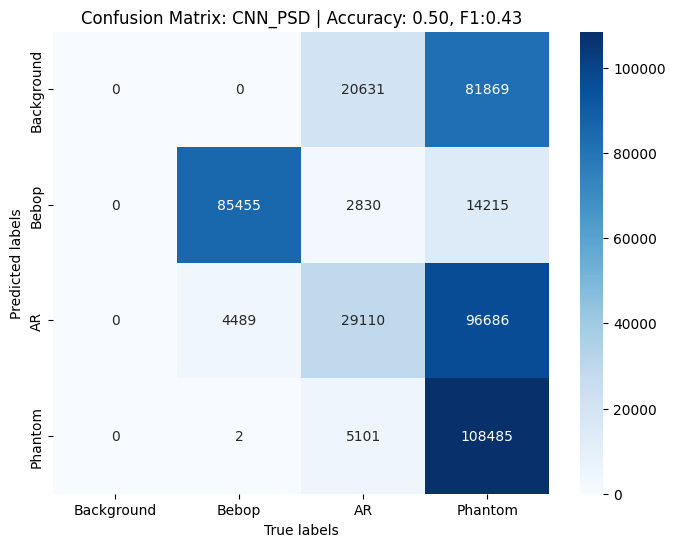

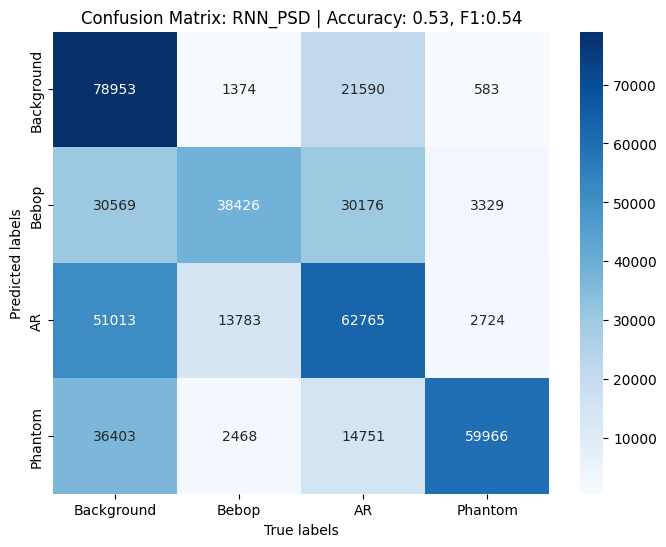

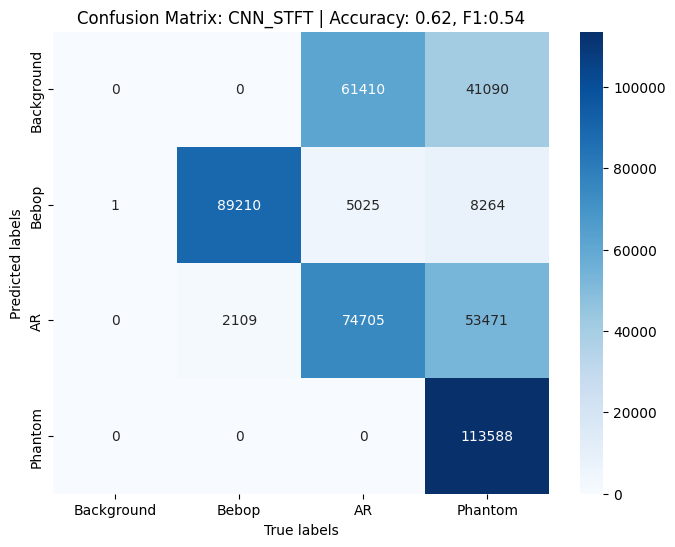

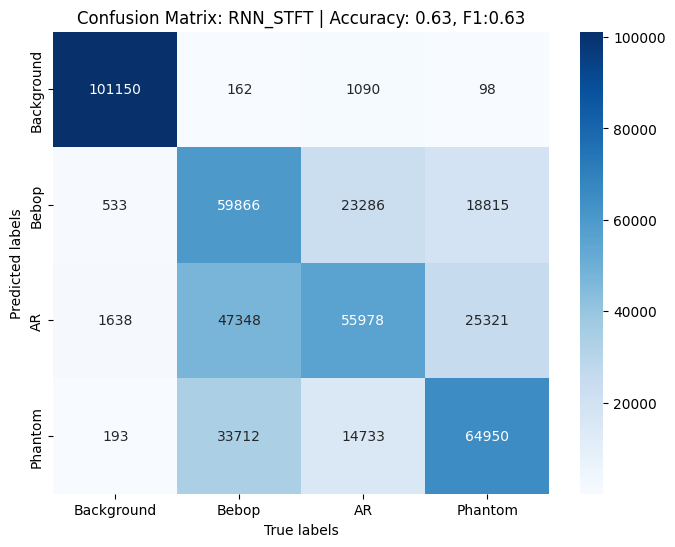

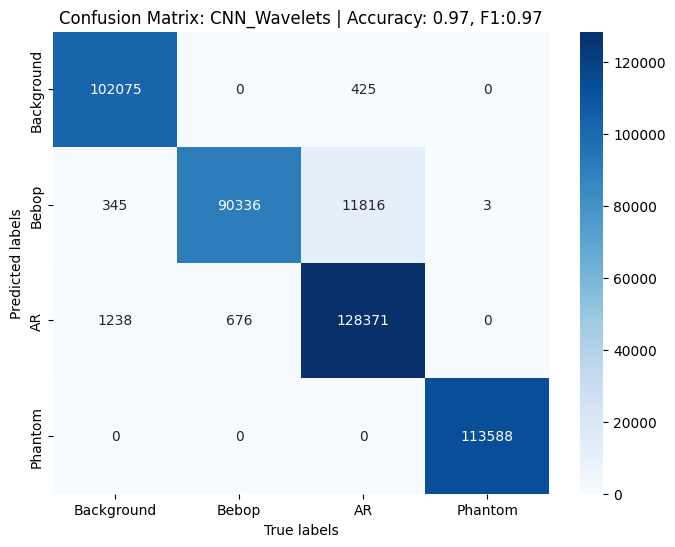

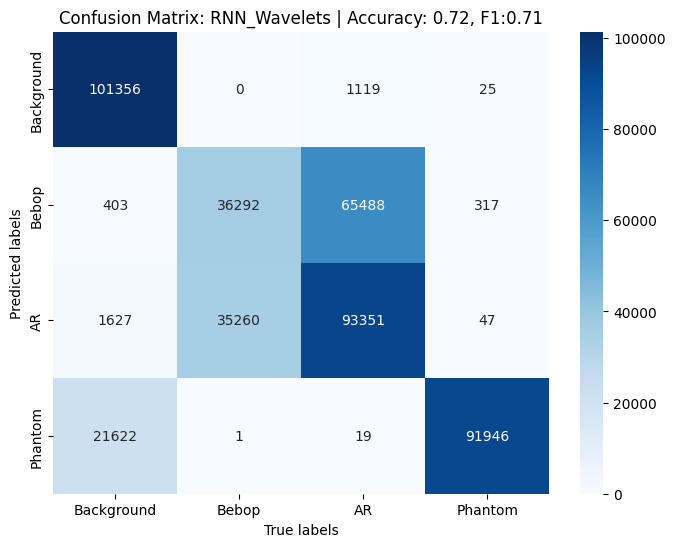

In [7]:
for feature in features:
    for model in models:
        data = []

        for fold in range(5):
            csv_path = os.path.join(results_path, feature, model, f"Results_{fold}.csv")
            with open(csv_path, encoding="utf-8") as csv_file:
                reader = csv.reader(csv_file, delimiter=",")
                data += [row for row in reader]

        df = pd.DataFrame(data, columns=columns)
        y_true, y_pred = df["True"], df["Predicted"]
        cf_matrix = confusion_matrix(y_true, y_pred)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")

        plt.figure(figsize=(8, 6))
        sns.heatmap(cf_matrix, cmap="Blues", annot=True, fmt=".0f", xticklabels=labels, yticklabels=labels)
        plt.xlabel('True labels')
        plt.ylabel('Predicted labels')
        plt.title(f'Confusion Matrix: {model}_{feature} | Accuracy: {acc:.2f}, F1:{f1:.2f}')
        plt.savefig(os.path.join(save_path, f"{model}_{feature}.png"))